# EDA - Síndrome dos Ovários Policísticos (SOP)

Análise exploratória do dataset clínico de SOP
(`data/polycystic/polycystic_ovary_syndrome/PCOS_data_without_infertility.xlsx`),
seguindo o mesmo padrão do notebook de EDA do câncer de mama (`01_eda_tabular`).

In [1]:
# Celula 1 - Imports
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.pcos.dataset import load_pcos_dataframe, get_pcos_info

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Imports carregados')

Imports carregados


In [2]:
# Celula 2 - Informacoes do dataset
info = get_pcos_info()
for k, v in info.items():
    if k != 'feature_names':
        print(f'{k}: {v}')
print(f'features: {len(info["feature_names"])} colunas')

name: Polycystic Ovary Syndrome Dataset
samples: 541
features: 41
classes: ['Sem SOP', 'Com SOP']
target: PCOS (Y/N)
features: 41 colunas


In [3]:
# Celula 3 - Carregar dados
df = load_pcos_dataframe()
target = 'PCOS (Y/N)'
print(f'Shape: {df.shape}')
print('\nPrimeiras 5 linhas:')
df.head()

Shape: (541, 42)

Primeiras 5 linhas:


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.300000,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [4]:
# Celula 4 - Qualidade dos dados
print('Info do DataFrame:')
df.info()

print('\nValores ausentes por coluna (top 15):')
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing.head(15) if missing.sum() > 0 else 'Nenhum valor ausente!')
print(f'\nTotal de celulas ausentes: {int(df.isna().sum().sum())} '
      f'({df.isna().sum().sum() / df.size * 100:.1f}%)')

print('\nEstatisticas descritivas:')
df.drop(columns=[target]).describe().T.head(15)

Info do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              541 non-null    int64  
 1   Age (yrs)               541 non-null    int64  
 2   Weight (Kg)             541 non-null    float64
 3   Height(Cm)              541 non-null    float64
 4   BMI                     541 non-null    float64
 5   Blood Group             541 non-null    int64  
 6   Pulse rate(bpm)         541 non-null    int64  
 7   RR (breaths/min)        541 non-null    int64  
 8   Hb(g/dl)                541 non-null    float64
 9   Cycle(R/I)              541 non-null    int64  
 10  Cycle length(days)      541 non-null    int64  
 11  Marraige Status (Yrs)   540 non-null    float64
 12  Pregnant(Y/N)           541 non-null    int64  
 13  No. of aborptions       541 non-null    int64  
 14  I   beta-HCG(mIU/mL)   

,count,mean,std,min,25%,50%,75%,max
Age (yrs),541.0,31.430684,5.411006,20.000000,28.000000,31.000000,35.000000,48.00
Weight (Kg),541.0,59.637153,11.028287,31.000000,52.000000,59.000000,65.000000,108.00
Height(Cm),541.0,156.484835,6.033545,137.000000,152.000000,156.000000,160.000000,180.00
BMI,541.0,24.311285,4.056399,12.417882,21.641274,24.238227,26.634958,38.90
Blood Group,541.0,13.802218,1.840812,11.000000,13.000000,14.000000,15.000000,18.00
Pulse rate(bpm),541.0,73.247689,4.430285,13.000000,72.000000,72.000000,74.000000,82.00
RR (breaths/min),541.0,19.243993,1.688629,16.000000,18.000000,18.000000,20.000000,28.00
Hb(g/dl),541.0,11.160037,0.866904,8.500000,10.500000,11.000000,11.700000,14.80
Cycle(R/I),541.0,2.560074,0.901950,2.000000,2.000000,2.000000,4.000000,5.00
Cycle length(days),541.0,4.940850,1.492020,0.000000,4.000000,5.000000,5.000000,12.00


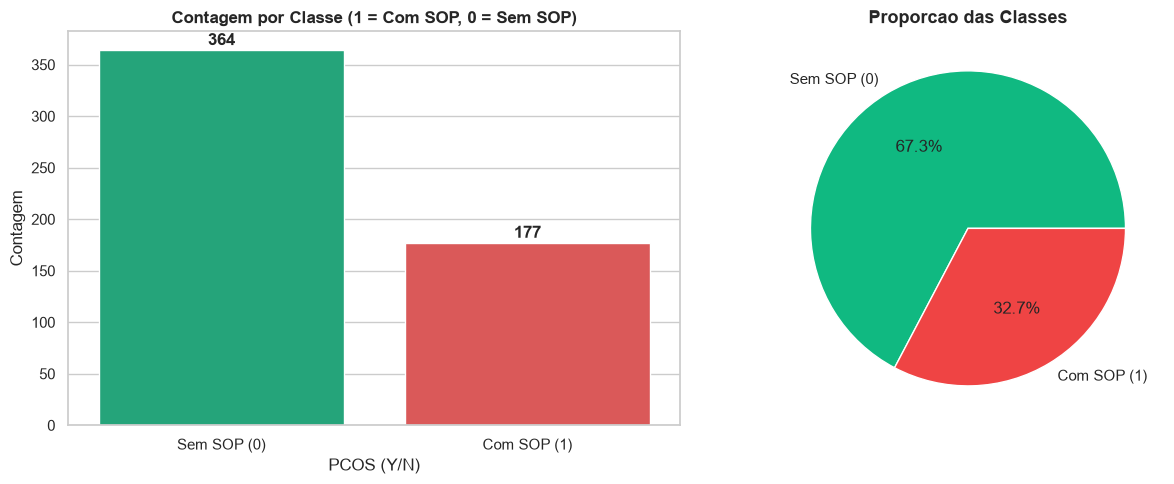

Distribuicao:
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64

Proporcao Com SOP: 32.7% | Sem SOP: 67.3%


In [5]:
# Celula 5 - Distribuicao da variavel target (1 = Com SOP, 0 = Sem SOP)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df[target].value_counts().sort_index()
sns.countplot(x=target, hue=target, data=df,
              palette=['#10b981', '#ef4444'], legend=False, ax=axes[0])
axes[0].set_title('Contagem por Classe (1 = Com SOP, 0 = Sem SOP)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(target)
axes[0].set_ylabel('Contagem')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Sem SOP (0)', 'Com SOP (1)'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

df[target].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['#10b981', '#ef4444'],
    labels=['Sem SOP (0)', 'Com SOP (1)'], ax=axes[1]
)
axes[1].set_title('Proporcao das Classes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

print('Distribuicao:')
print(df[target].value_counts().sort_index())
print(f'\nProporcao Com SOP: {df[target].mean()*100:.1f}% | Sem SOP: {(1-df[target].mean())*100:.1f}%')

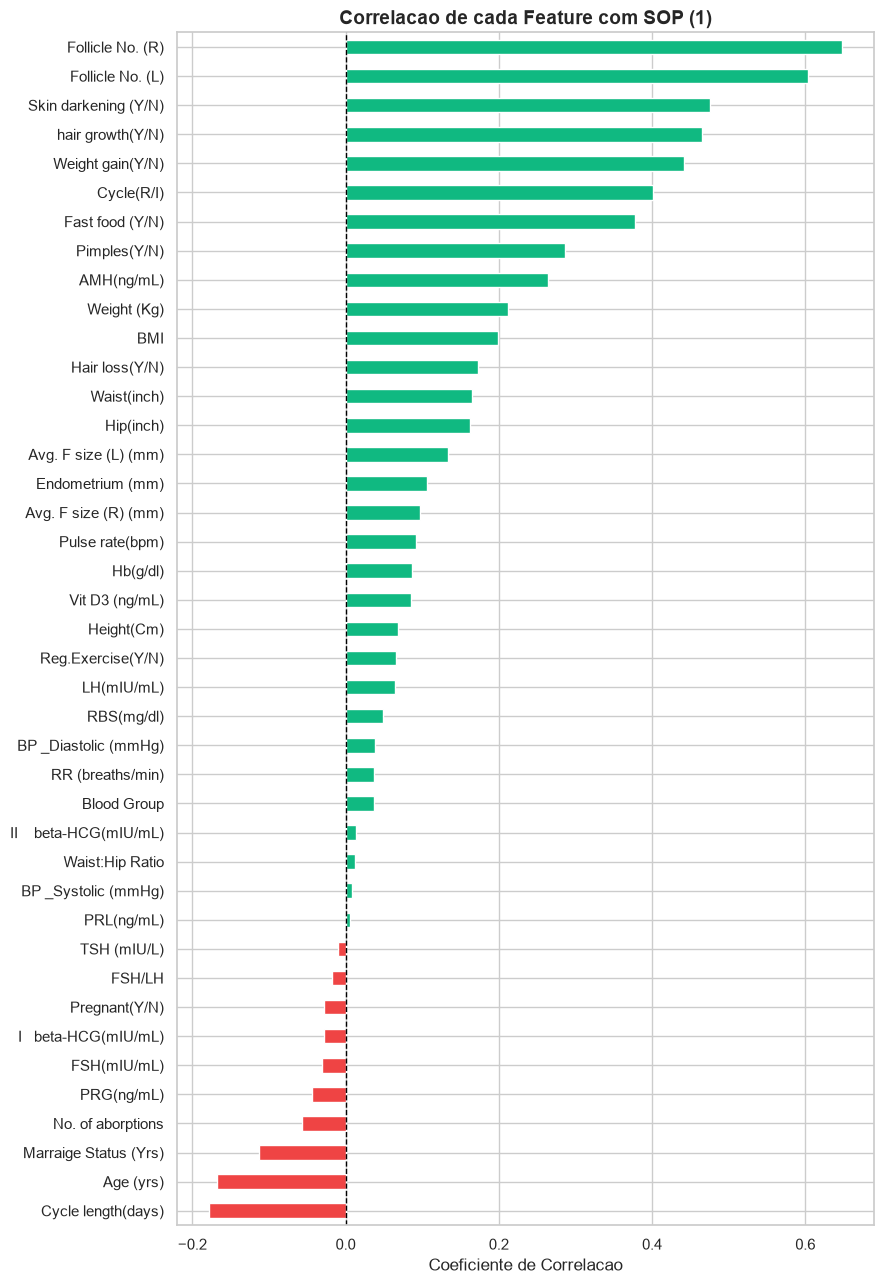

Top 10 features mais correlacionadas com SOP (1):
Follicle No. (R)        0.648
Follicle No. (L)        0.603
Skin darkening (Y/N)    0.476
hair growth(Y/N)        0.465
Weight gain(Y/N)        0.441
Cycle(R/I)              0.402
Fast food (Y/N)         0.378
Pimples(Y/N)            0.286
AMH(ng/mL)              0.264
Weight (Kg)             0.212
dtype: float64


In [6]:
# Celula 6 - Correlacao das features com o target
features = [c for c in df.columns if c != target]
corr_with_target = df[features].corrwith(df[target]).sort_values()

plt.figure(figsize=(9, 13))
colors = ['#ef4444' if x < 0 else '#10b981' for x in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors)
plt.title('Correlacao de cada Feature com SOP (1)', fontsize=14, fontweight='bold')
plt.xlabel('Coeficiente de Correlacao')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print('Top 10 features mais correlacionadas com SOP (1):')
print(corr_with_target.sort_values(ascending=False).head(10).round(3))

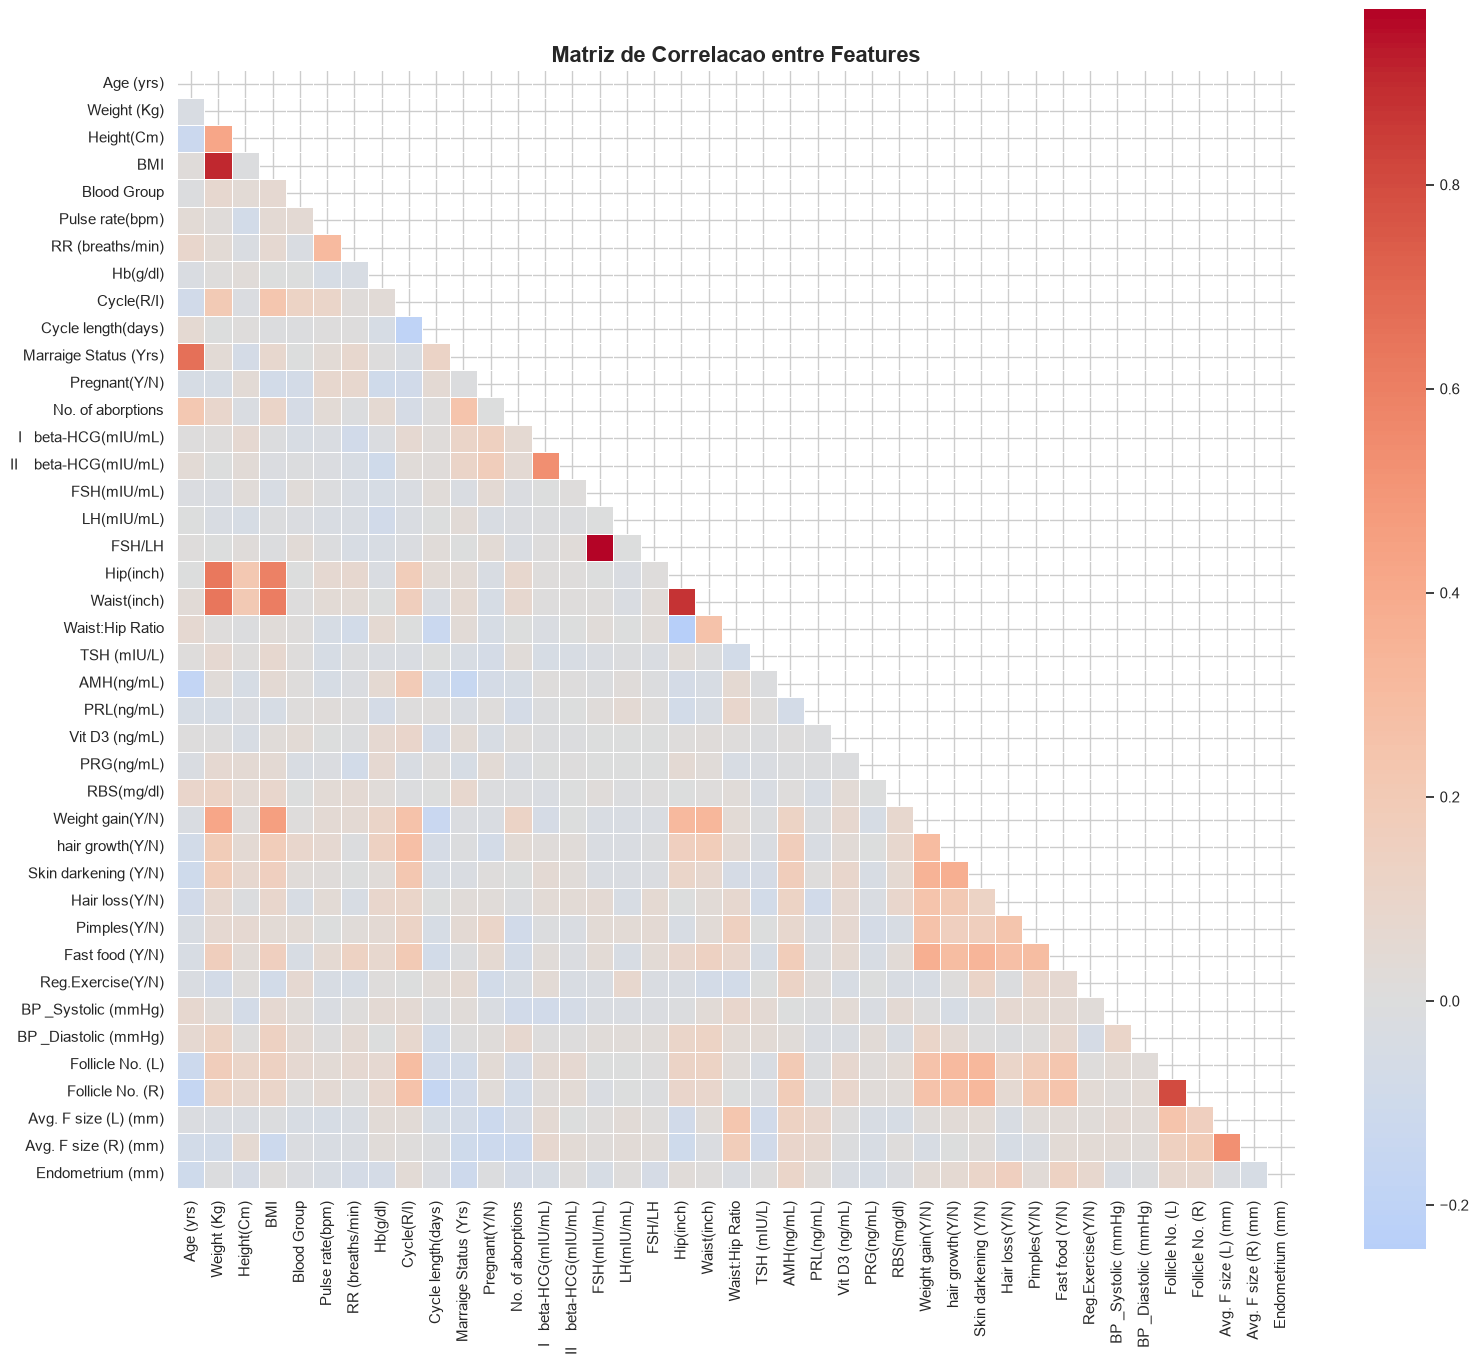

Features altamente correlacionadas (|r| > 0.9):
  - BMI <-> Weight (Kg): 0.902
  - FSH/LH <-> FSH(mIU/mL): 0.972


In [7]:
# Celula 7 - Matriz de correlacao completa
plt.figure(figsize=(16, 14))
corr_matrix = df[features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, square=True, linewidths=0.5)
plt.title('Matriz de Correlacao entre Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('Features altamente correlacionadas (|r| > 0.9):')
high = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high.append((corr_matrix.columns[i], corr_matrix.columns[j], round(corr_matrix.iloc[i, j], 3)))
for c1, c2, r in high[:10]:
    print(f'  - {c1} <-> {c2}: {r}')

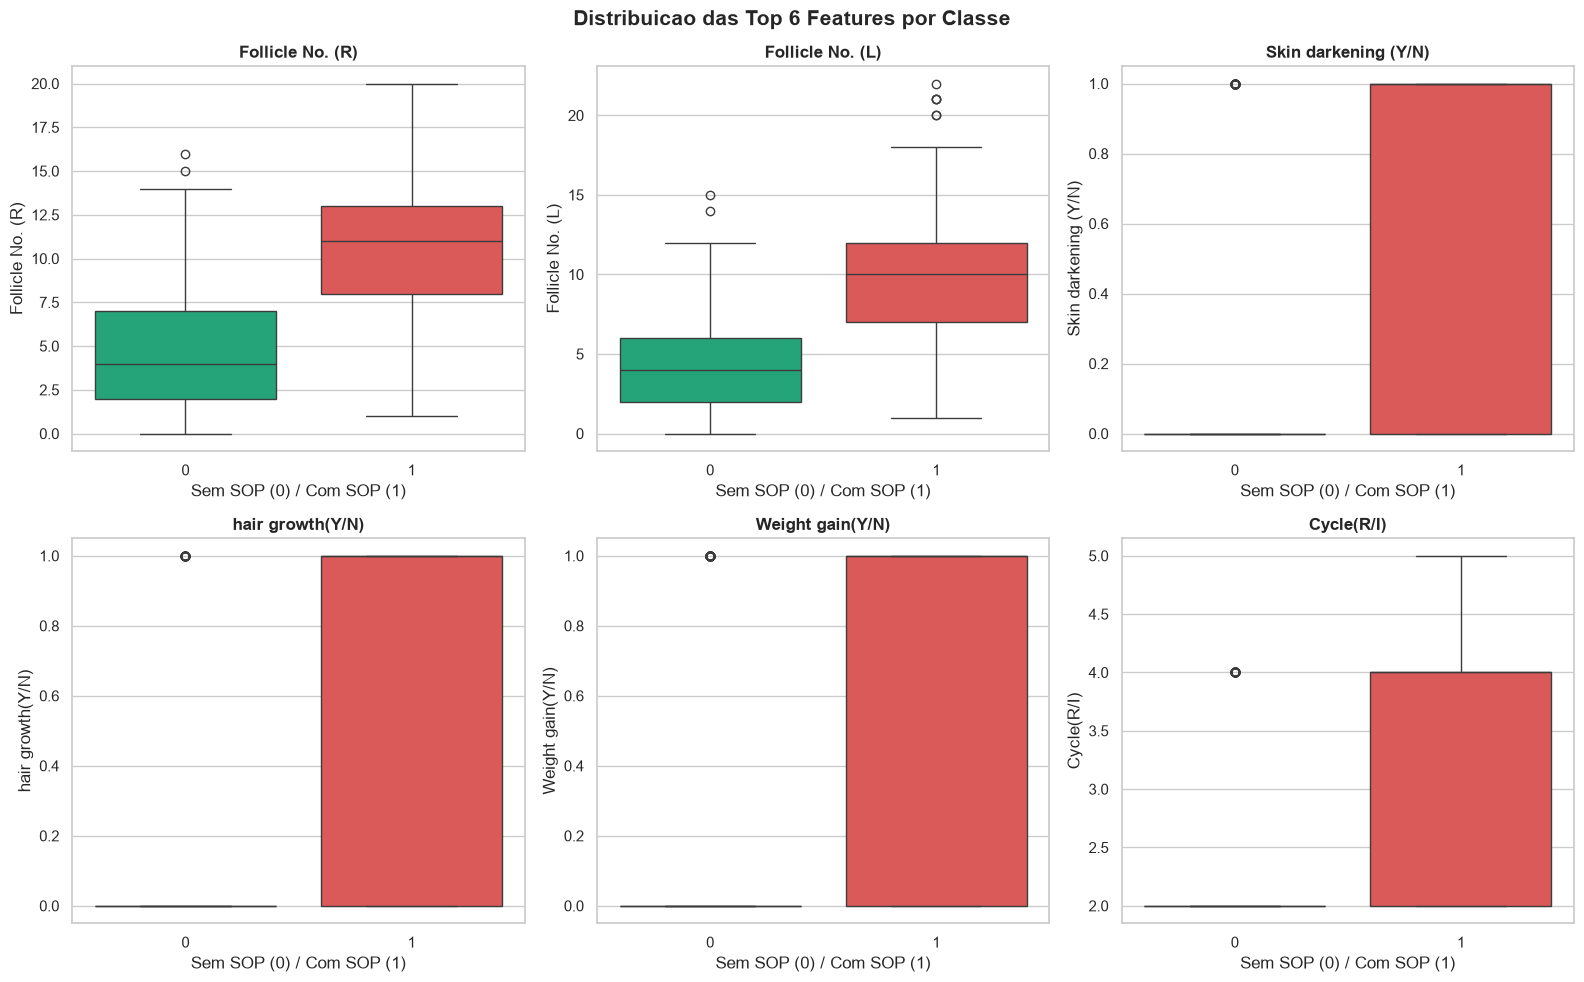

In [8]:
# Celula 8 - Boxplots das top 6 features por classe
top_features = corr_with_target.abs().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for idx, feature in enumerate(top_features):
    sns.boxplot(x=target, y=df[feature], hue=target, data=df,
                palette=['#10b981', '#ef4444'], legend=False, ax=axes[idx])
    axes[idx].set_title(feature, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Sem SOP (0) / Com SOP (1)')
plt.suptitle('Distribuicao das Top 6 Features por Classe', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [9]:
# Celula 9 - Estatisticas por classe
print('Estatisticas descritivas por classe (media das features):')
stats = df.groupby(target)[features].mean().T
stats.columns = ['Sem SOP (0)', 'Com SOP (1)']
stats['diferenca'] = (stats['Com SOP (1)'] - stats['Sem SOP (0)']).round(3)
stats.round(3).head(15)

Estatisticas descritivas por classe (media das features):


,Sem SOP (0),Com SOP (1),diferenca
Age (yrs),32.066,30.124,-1.942
Weight (Kg),58.009,62.986,4.977
Height(Cm),156.198,157.075,0.877
BMI,23.747,25.471,1.724
Blood Group,13.755,13.898,0.143
Pulse rate(bpm),72.964,73.831,0.866
RR (breaths/min),19.201,19.333,0.133
Hb(g/dl),11.107,11.268,0.161
Cycle(R/I),2.308,3.079,0.771
Cycle length(days),5.126,4.559,-0.567


In [10]:
# Celula 10 - Insights e conclusoes
print('''
=========== INSIGHTS DA ANALISE EXPLORATORIA ===========
1. DATASET: 541 amostras, 41 features clinicas + target 'PCOS (Y/N)'.
2. VALORES AUSENTES: o dataset possui celulas NaN (AMH, FSH/LH e outras)
   -> usar SimpleImputer (mediana) no pipeline.
3. CLASSES: distribuicao relativamente balanceada; manter stratify no split.
4. FEATURES MAIS RELEVANTES: contagens de foliculos, FSH, LH e AMH
   aparecem entre as mais correlacionadas com SOP.
5. MULTICOLINEARIDADE: varias medidas correlacionadas > 0.9 -
   modelos de arvore lidam bem com isso.
6. PRE-PROCESSAMENTO: imputacao por mediana + StandardScaler + stratified split.
=========================================================
''')


=========== INSIGHTS DA ANALISE EXPLORATORIA ===========
1. DATASET: 541 amostras, 41 features clinicas + target 'PCOS (Y/N)'.
2. VALORES AUSENTES: o dataset possui celulas NaN (AMH, FSH/LH e outras)
   -> usar SimpleImputer (mediana) no pipeline.
3. CLASSES: distribuicao relativamente balanceada; manter stratify no split.
4. FEATURES MAIS RELEVANTES: contagens de foliculos, FSH, LH e AMH
   aparecem entre as mais correlacionadas com SOP.
5. MULTICOLINEARIDADE: varias medidas correlacionadas > 0.9 -
   modelos de arvore lidam bem com isso.
6. PRE-PROCESSAMENTO: imputacao por mediana + StandardScaler + stratified split.

